# Evidence for Histogram mismatch between different cases
### Clearly see that different MRI camera vendors have their different intensity distribution
This highlights the need to perform strong value scaling.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import animation
import random
#PATH PROCESS
import os
from tqdm import tqdm


import helpers

# the one library to handle nii images
import nibabel as nib

In [2]:
PROBLEM_TYPE = "CINE" 
IMAGE_TYPE = "4CH"
DATASET_FOLDER_PATH = os.path.abspath(f"..\\CMR-MULTI\\{PROBLEM_TYPE}_MULTI\\{IMAGE_TYPE}_TR\\image")

all_images = helpers.get_all_np_images(DATASET_FOLDER_PATH)

max value in all pixels for the image number 61 is 4218.0283203125
max value in all pixels for the image number 39 is 1707.78076171875
max value in all pixels for the image number 83 is 4057.89990234375


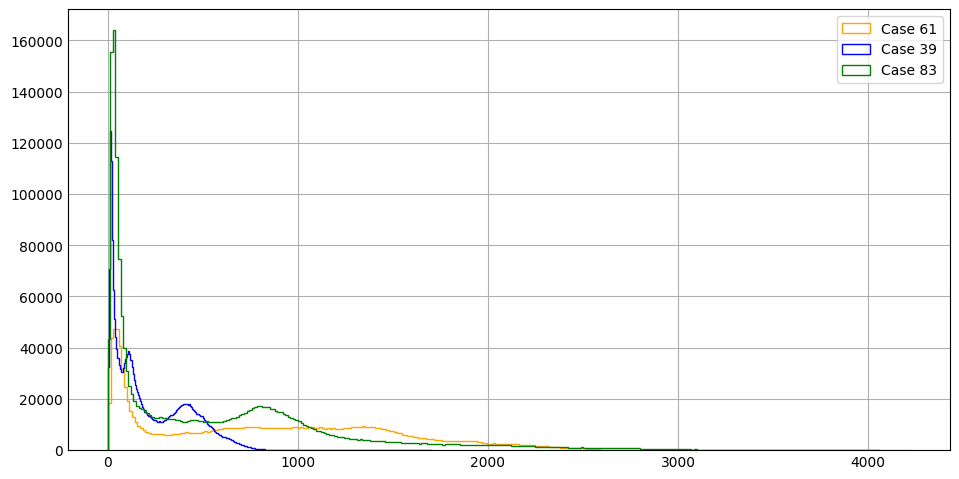

In [3]:
random_indices = [61, 39, 83] #np.random.randint(0, len(all_images), 3)
randomly_selected_images = [all_images[i] for i in random_indices]
colors = ['orange', 'blue', 'green']

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Case {idx}')

ax.legend()
plt.show()

mean of all max values: 3302.8539688248484
max of all max values: 7428.8603515625, Min of all max values is 601.9413452148438
std of all max values: 1340.7145645376886


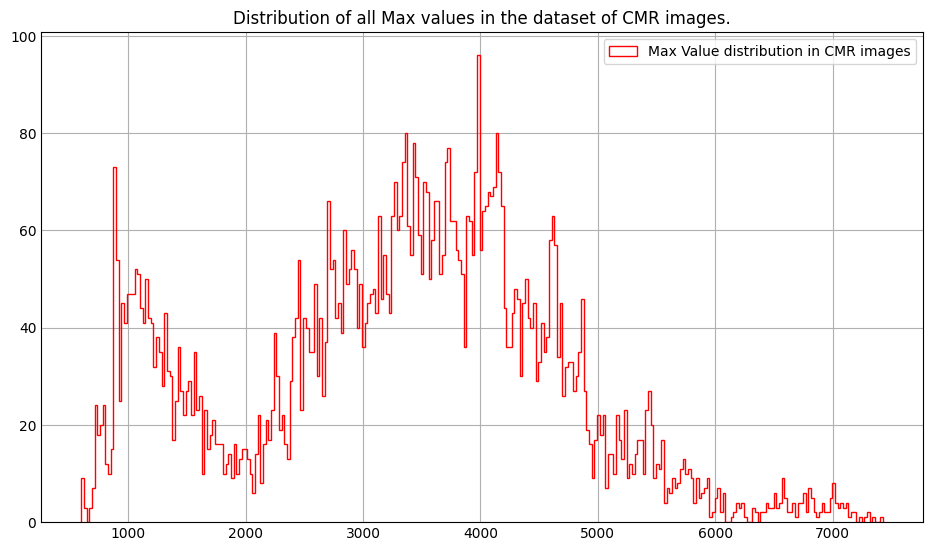

In [4]:
# Extracting the Mean and STD of all max values
all_max_values = np.array([])
for image in all_images:
    for d in range(image.shape[2]):
        all_max_values = np.append(all_max_values, np.max(image[:,:, d]))

print(f"mean of all max values: {np.mean(all_max_values)}")
print(f"max of all max values: {np.max(all_max_values)}, Min of all max values is {np.min(all_max_values)}")
print(f"std of all max values: {np.std(all_max_values)}")

plt.subplots(figsize=(9, 5))
plt.hist(all_max_values, bins=300, linewidth=1.0, histtype='step', color='red', label=f'Max Value distribution in CMR images')
plt.title('Distribution of all Max values in the dataset of CMR images.')
plt.legend()
plt.show()

### Trying out the global min-max scaler

(217025575, 1)
max value in all pixels for the image number 61 is 0.567789421351194
max value in all pixels for the image number 39 is 0.229884623064634
max value in all pixels for the image number 83 is 0.5462345111239382


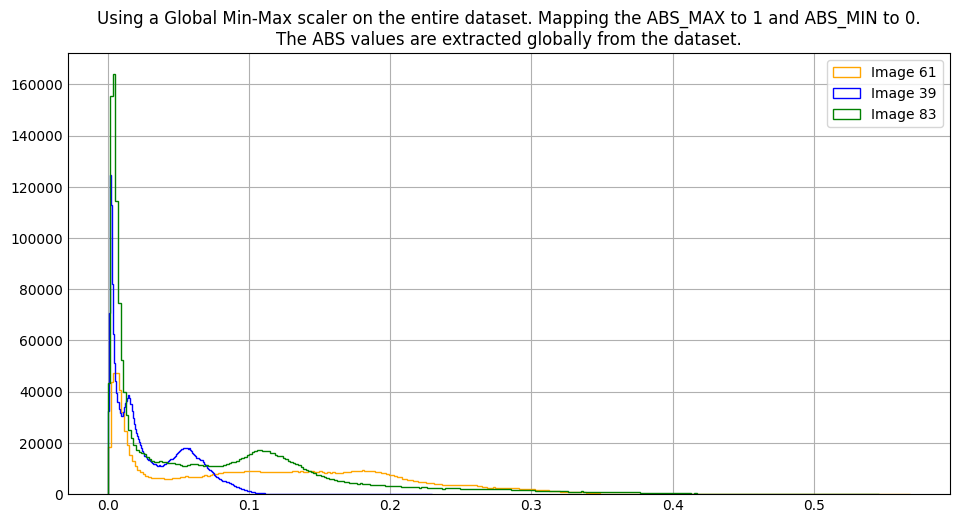

In [5]:
from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

all_pixels = np.array(helpers.recursive_flatten(all_images)).reshape(-1, 1)
print(all_pixels.shape)
scaler = scaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = scaler.transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

plt.title('Using a Global Min-Max scaler on the entire dataset. Mapping the ABS_MAX to 1 and ABS_MIN to 0.\nThe ABS values are extracted globally from the dataset.')
ax.legend()
plt.show()

### Trying out the local min-max scaler

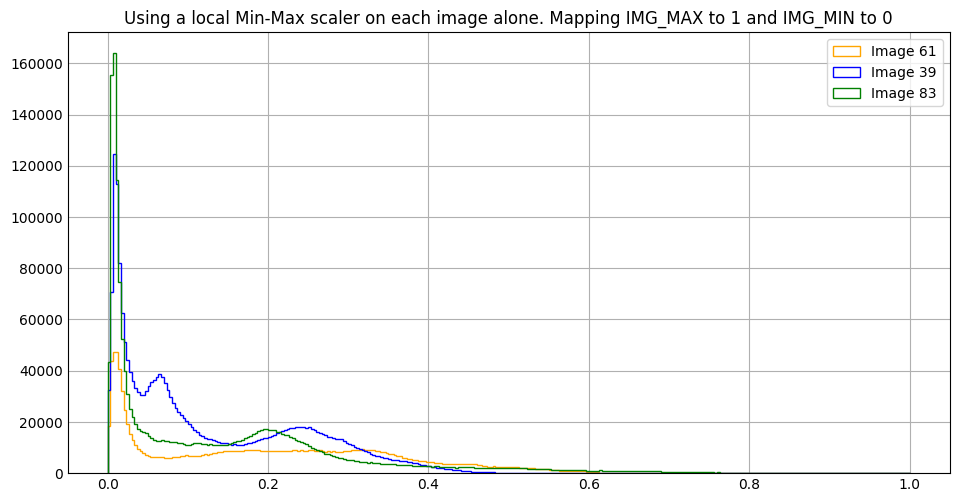

In [6]:
from sklearn.preprocessing import MinMaxScaler

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    scaler = MinMaxScaler()
    img = scaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

plt.title('Using a local Min-Max scaler on each image alone. Mapping IMG_MAX to 1 and IMG_MIN to 0')
ax.legend()
plt.show()

After some analysis, we are going to ditch the global min-max scaler and use the local min-max scaler.
This is because an outlier image may be input from another camera vendor that has a max value bigger than our computed global ABS_MAX value and such will break our model during inference.
Another side case can happen is there is a small piece of metal in the MRI image, metals give out signal output near to 50k, clearly surpassing our ABS_MAX value.

Generally speaking, using the local min-max scaler is more reliable in normal cases than the global min-max scaler, however if a certain anomalous case as a case containing a metal piece, this will cause the entire classification of this anomalous case to be affected negatively.
We will accept the risk of misclassifying a single anomalous case than to poison the scaling of our entire dataset from individual anomalous cases.

max value in all pixels for the image number 61 is 1.0394609088006985
max value in all pixels for the image number 39 is 0.4208533484851056
max value in all pixels for the image number 83 is 1.0


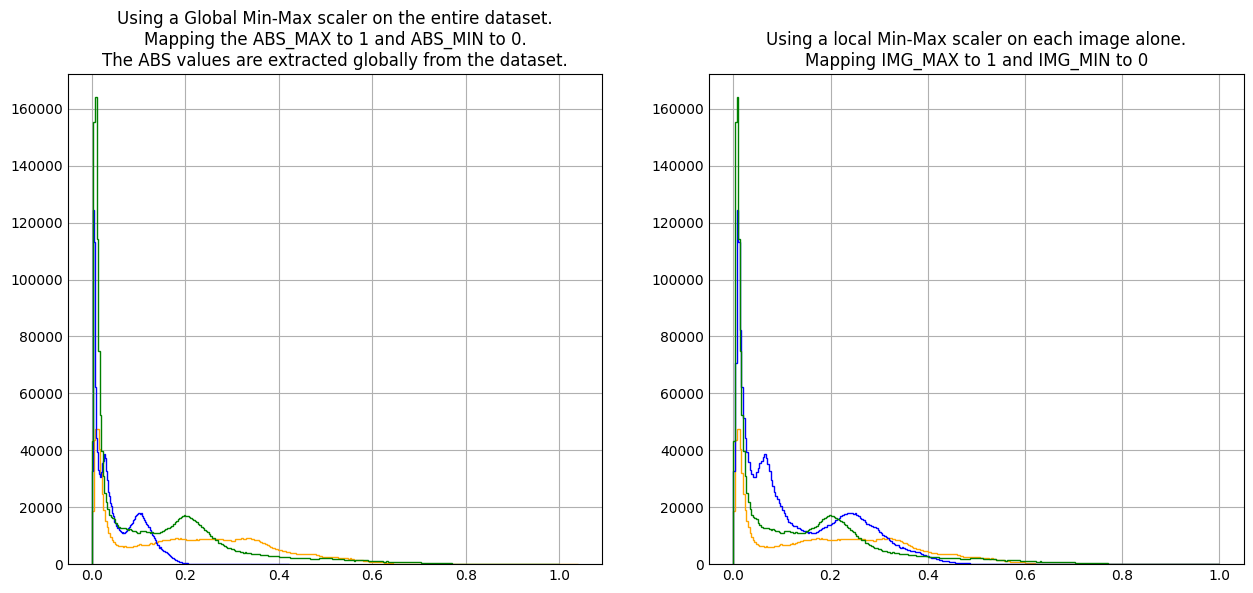

In [7]:
plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = scaler.transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax[0].hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax[0].set_title('Using a Global Min-Max scaler on the entire dataset.\nMapping the ABS_MAX to 1 and ABS_MIN to 0.\nThe ABS values are extracted globally from the dataset.')
#ax[0].legend()
#plt.show()


for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    scaler = MinMaxScaler()
    img = scaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)

    ax[1].hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax[1].set_title('Using a local Min-Max scaler on each image alone.\nMapping IMG_MAX to 1 and IMG_MIN to 0')
#ax.legend()
plt.show()

(217025575, 1)
max value in all pixels for the image number 61 is 5.150242523998599
max value in all pixels for the image number 39 is 7.641320562075103
max value in all pixels for the image number 83 is 5.545040944453135


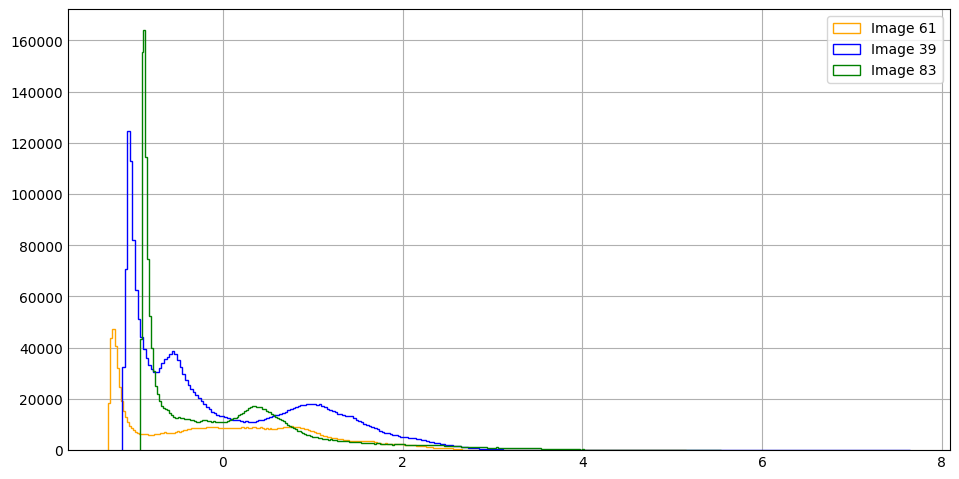

In [8]:
from sklearn.preprocessing import StandardScaler

zscaler = StandardScaler()

print(all_pixels.shape)
zscaler = zscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = zscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")

    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()
    

(217025575, 1)
max value in all pixels for the image number 61 is 2.9823227434631123
max value in all pixels for the image number 39 is 4.689378379145513
max value in all pixels for the image number 83 is 4.383445864475782


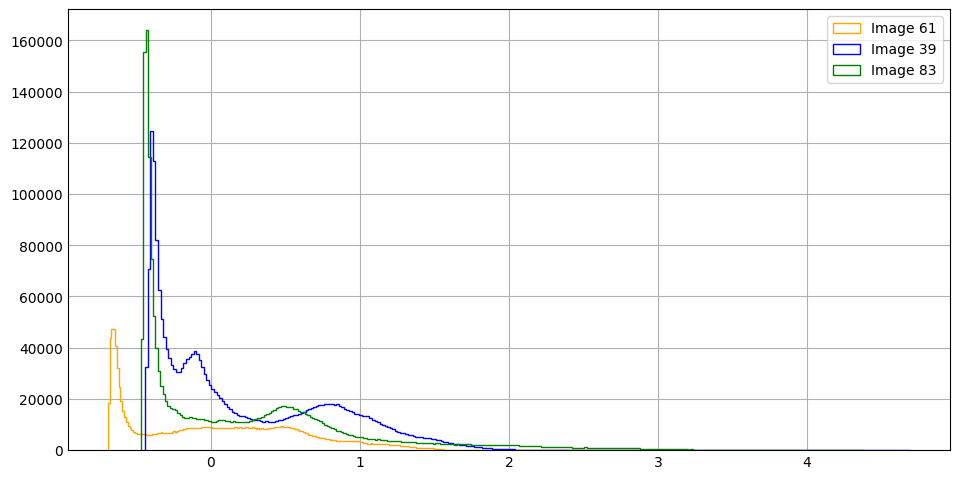

In [9]:
from sklearn.preprocessing import RobustScaler

rbscaler = RobustScaler()

print(all_pixels.shape)
rbscaler = rbscaler.fit(all_pixels)

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img = rbscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

(217025575, 1)


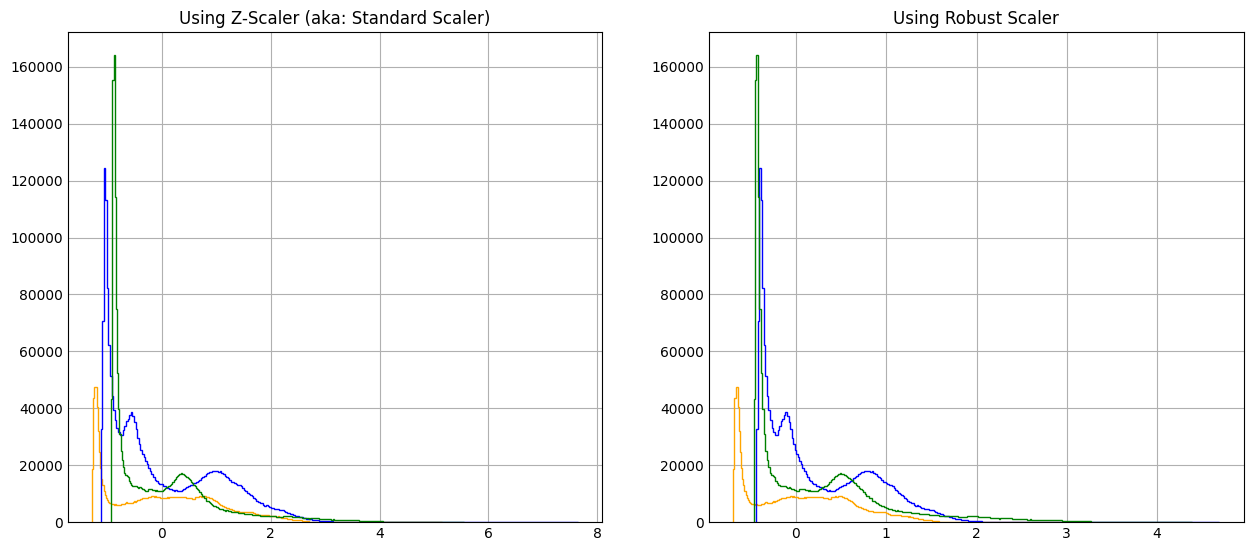

In [10]:
from sklearn.preprocessing import StandardScaler, RobustScaler

zscaler = StandardScaler()

print(all_pixels.shape)
zscaler = zscaler.fit(all_pixels)

rbscaler = RobustScaler()
rbscaler = rbscaler.fit(all_pixels)


plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img1 = zscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img1)
    ax[0].hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Case {idx}')



    img2 = rbscaler.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img2)
    ax[1].hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Case {idx}')

ax[0].set_title('Using Z-Scaler (aka: Standard Scaler)')
ax[1].set_title('Using Robust Scaler')


#ax.legend()
plt.show()

### Looks like the StandardScaler (Z-score scaler) achieves a good histogrm matching between the 3 randomly selected cases
#### Now let's try to manually clip out the outlier data and rerun the Z-Scaler

In [11]:
def clip_outliers_from_img(image:np.ndarray, low_percentile=None, high_percentile=99):
    original_shape = image.shape

    perc1 = low_percentile if low_percentile else 0
    if high_percentile:
        p1, p99 = np.percentile(image.reshape(-1, 1), [perc1, high_percentile])
    #print(f"Low Percentile is {p1}, 99 Percentile is {p99}")
    perc1 = p1 if low_percentile else None
    pixels = np.clip(image.reshape(-1, 1), perc1, p99)
    clipped_img = pixels.reshape(original_shape)
    return clipped_img, pixels


def clip_and_scale(img, clip=True, scaler=None, low_percentile=None, high_percentile=99):
    new_img = img.copy()
    if clip: new_img, _ = clip_outliers_from_img(img, low_percentile=low_percentile, high_percentile=high_percentile)
    if scaler:
        orig_shape = new_img.shape
        new_img = scaler.transform(new_img.reshape(-1, 1)).reshape(orig_shape)
    return new_img

100%|██████████| 105/105 [00:46<00:00,  2.26it/s]


finished clipping 105 images
finished flattening 105 images to 217025575 pixels
finished training the scaler
max value in all pixels for the image number 61 is 2.39638756281599
max value in all pixels for the image number 39 is 2.52392965766729
max value in all pixels for the image number 83 is 3.4039983869051667


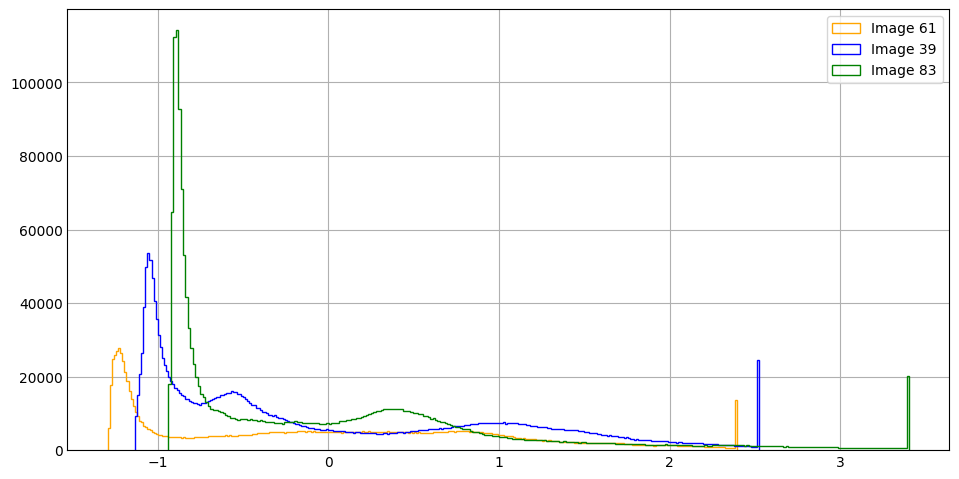

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


all_pixels_after_clipping = np.array([]).reshape(-1, 1)
for img in tqdm(all_images):
    clipped_img, pixels = clip_outliers_from_img(img)
    all_pixels_after_clipping = np.concatenate((all_pixels_after_clipping, pixels))

print(f"finished clipping {len(all_images)} images")

#all_pixels_after_clipping = helpers.recursive_flatten(clipped_images)
all_pixels_after_clipping = np.array(all_pixels_after_clipping).reshape(-1, 1)

print(f"finished flattening {len(all_images)} images to {len(all_pixels_after_clipping)} pixels")

zscaler_clipped = StandardScaler()
zscaler_clipped = zscaler_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = zscaler_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

finished training the scaler


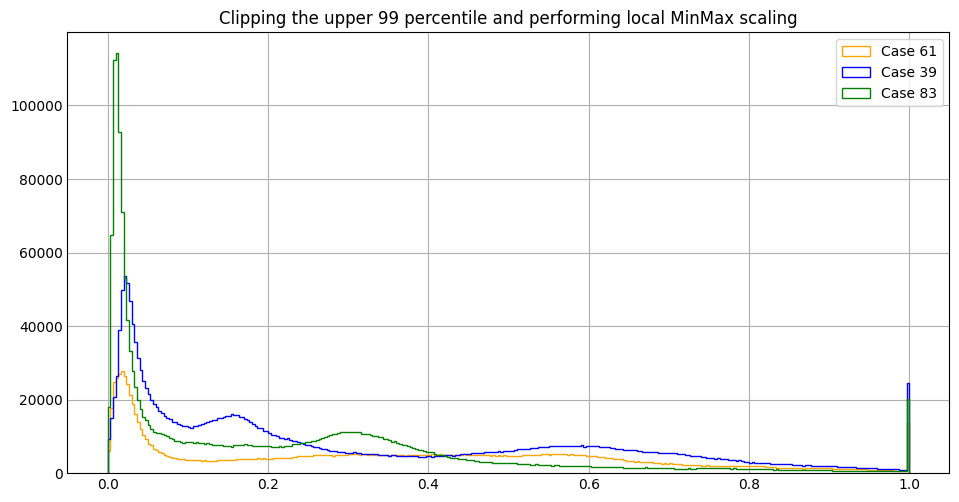

In [14]:
minmax_clipped = MinMaxScaler()
#minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    #print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Case {idx}')

plt.title('Clipping the upper 99 percentile and performing local MinMax scaling')
ax.legend()
plt.show()

finished training the scaler
max value in all pixels for the image number 71 is 1.6235243823516532
max value in all pixels for the image number 32 is 1.4420575944126344
max value in all pixels for the image number 86 is 1.5334997090437847


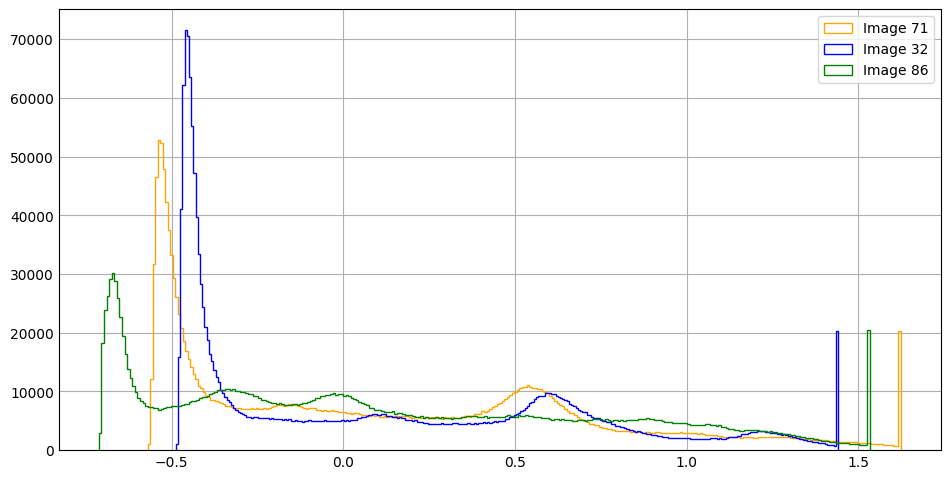

In [10]:
minmax_clipped = RobustScaler()
minmax_clipped = minmax_clipped.fit(all_pixels_after_clipping)

print(f"finished training the scaler")

plt.style.use('_mpl-gallery')
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, img in enumerate(randomly_selected_images):
    idx = random_indices[i]
    img_shape = img.shape #preserving the image shape
    img, _ = clip_outliers_from_img(img) #Clip outliers
    img = minmax_clipped.fit_transform(img.reshape(-1, 1)).reshape(img_shape) #flattening the image, then scaling it, then restoring the original shape
    all_pixel_values = helpers.recursive_flatten(img)
    max_val = max(all_pixel_values)
    print(f"max value in all pixels for the image number {idx} is {max_val}")
    ax.hist(all_pixel_values, bins=300, linewidth=1.0, histtype='step', color=colors[i], label=f'Image {idx}')

ax.legend()
plt.show()

### Comparison between 3 samples only is not very accurate, Let's compare more histograms together to get a more accurate representation of the different distributions

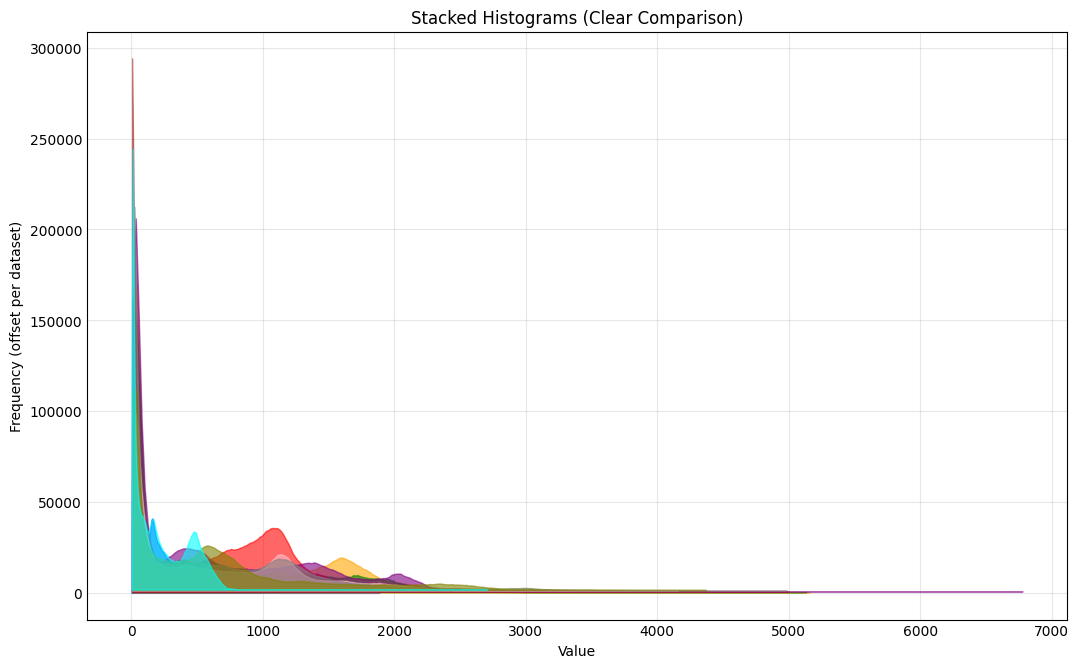

In [11]:
import numpy as np
import matplotlib.pyplot as plt

random_indices = np.random.randint(0, len(all_images), 10)
randomly_selected_images = [all_images[i] for i in random_indices]

colors = ['blue', 'orange', 'green', 'red', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

bins = 300
offset = 200  # controls vertical separation between histograms

plt.figure(figsize=(10, 6))

for i, img in enumerate(randomly_selected_images):
    data = helpers.recursive_flatten(img)
    hist, bin_edges = np.histogram(data, bins=bins)

    xs = (bin_edges[:-1] + bin_edges[1:]) / 2

    # shift each histogram upward
    plt.fill_between(xs, i * offset, hist + i * offset,
                 color=colors[i], alpha=0.6)

plt.xlabel("Value")
plt.ylabel("Frequency (offset per dataset)")
plt.title("Stacked Histograms (Clear Comparison)")
plt.grid(alpha=0.3)


plt.show()

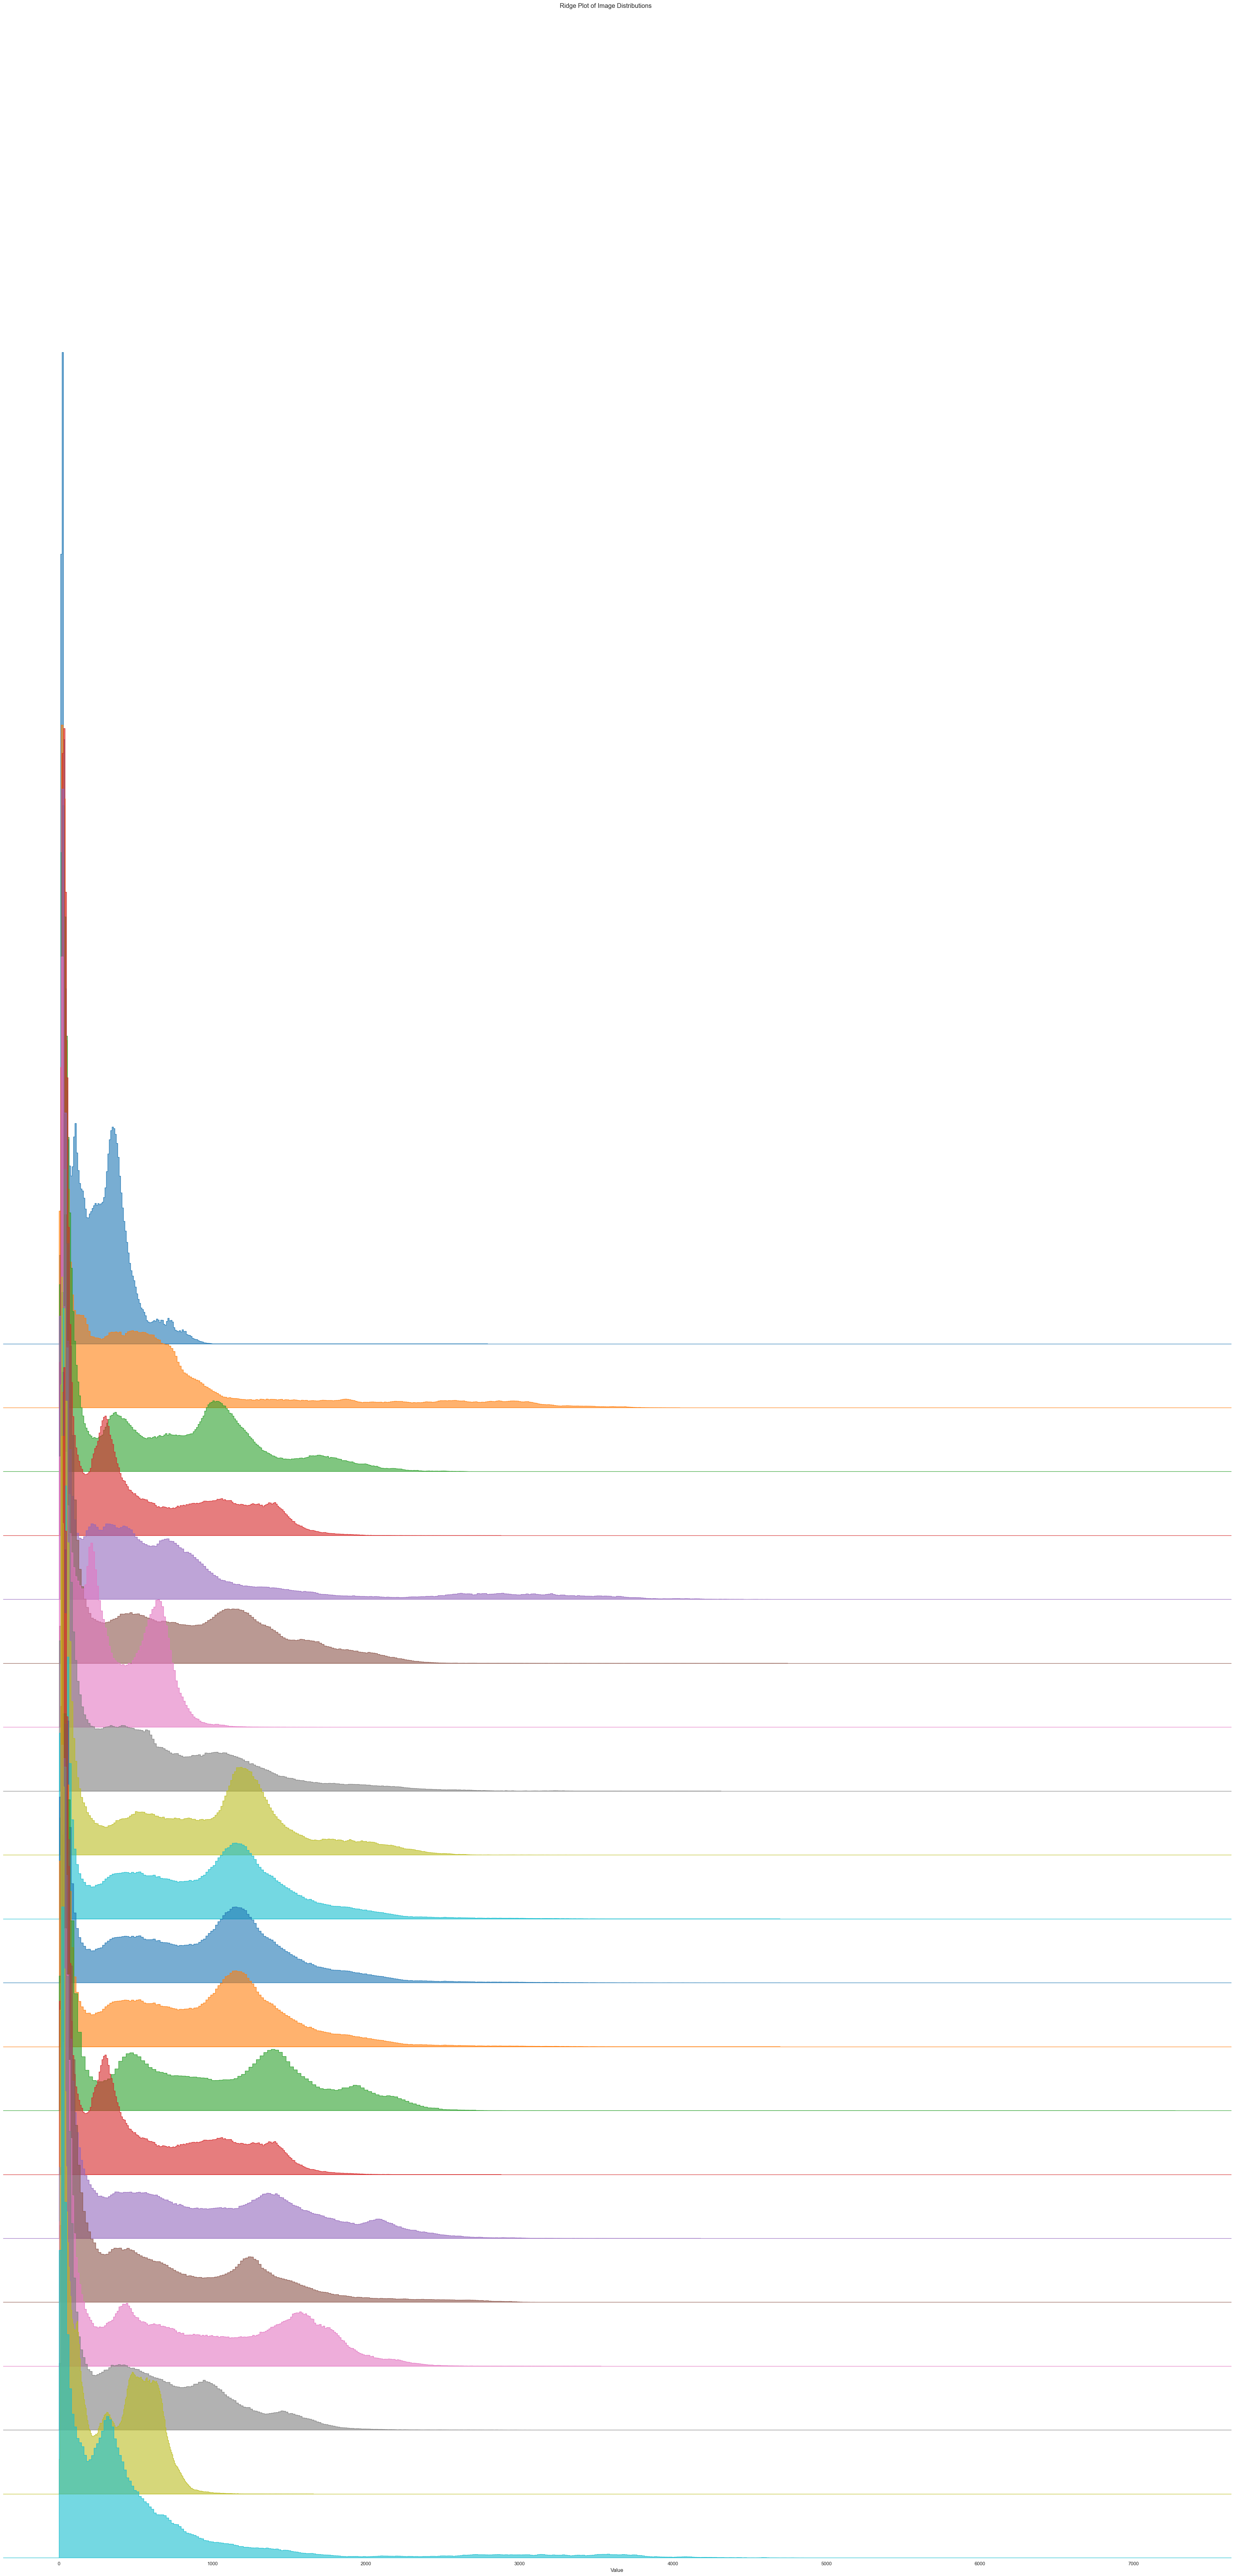

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
random_indices = np.random.randint(0, len(all_images), 20)
randomly_selected_images = [all_images[i] for i in random_indices]

records = []

df = pd.concat([
pd.DataFrame({
    "value": helpers.recursive_flatten(img),
    "dataset": f"Img {i}"
})
for i, img in enumerate(randomly_selected_images)
])
        

# Plot
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="dataset", hue="dataset", aspect=10, height=4, palette="tab10")

# Draw density curves
g.map(sns.histplot, "value", bins=300, stat="density", element="step", fill=True, alpha=0.6)


# Add baseline
g.map(plt.axhline, y=0, lw=1, clip_on=False)

# Overlap plots
g.figure.subplots_adjust(hspace=-0.95)

# Remove axes details
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Value")
plt.suptitle("Ridge Plot of Image Distributions", y=1.02)

plt.show()

(217025575, 1)


Text(0.5, 1.02, 'Ridge Plot of Image Distributions')

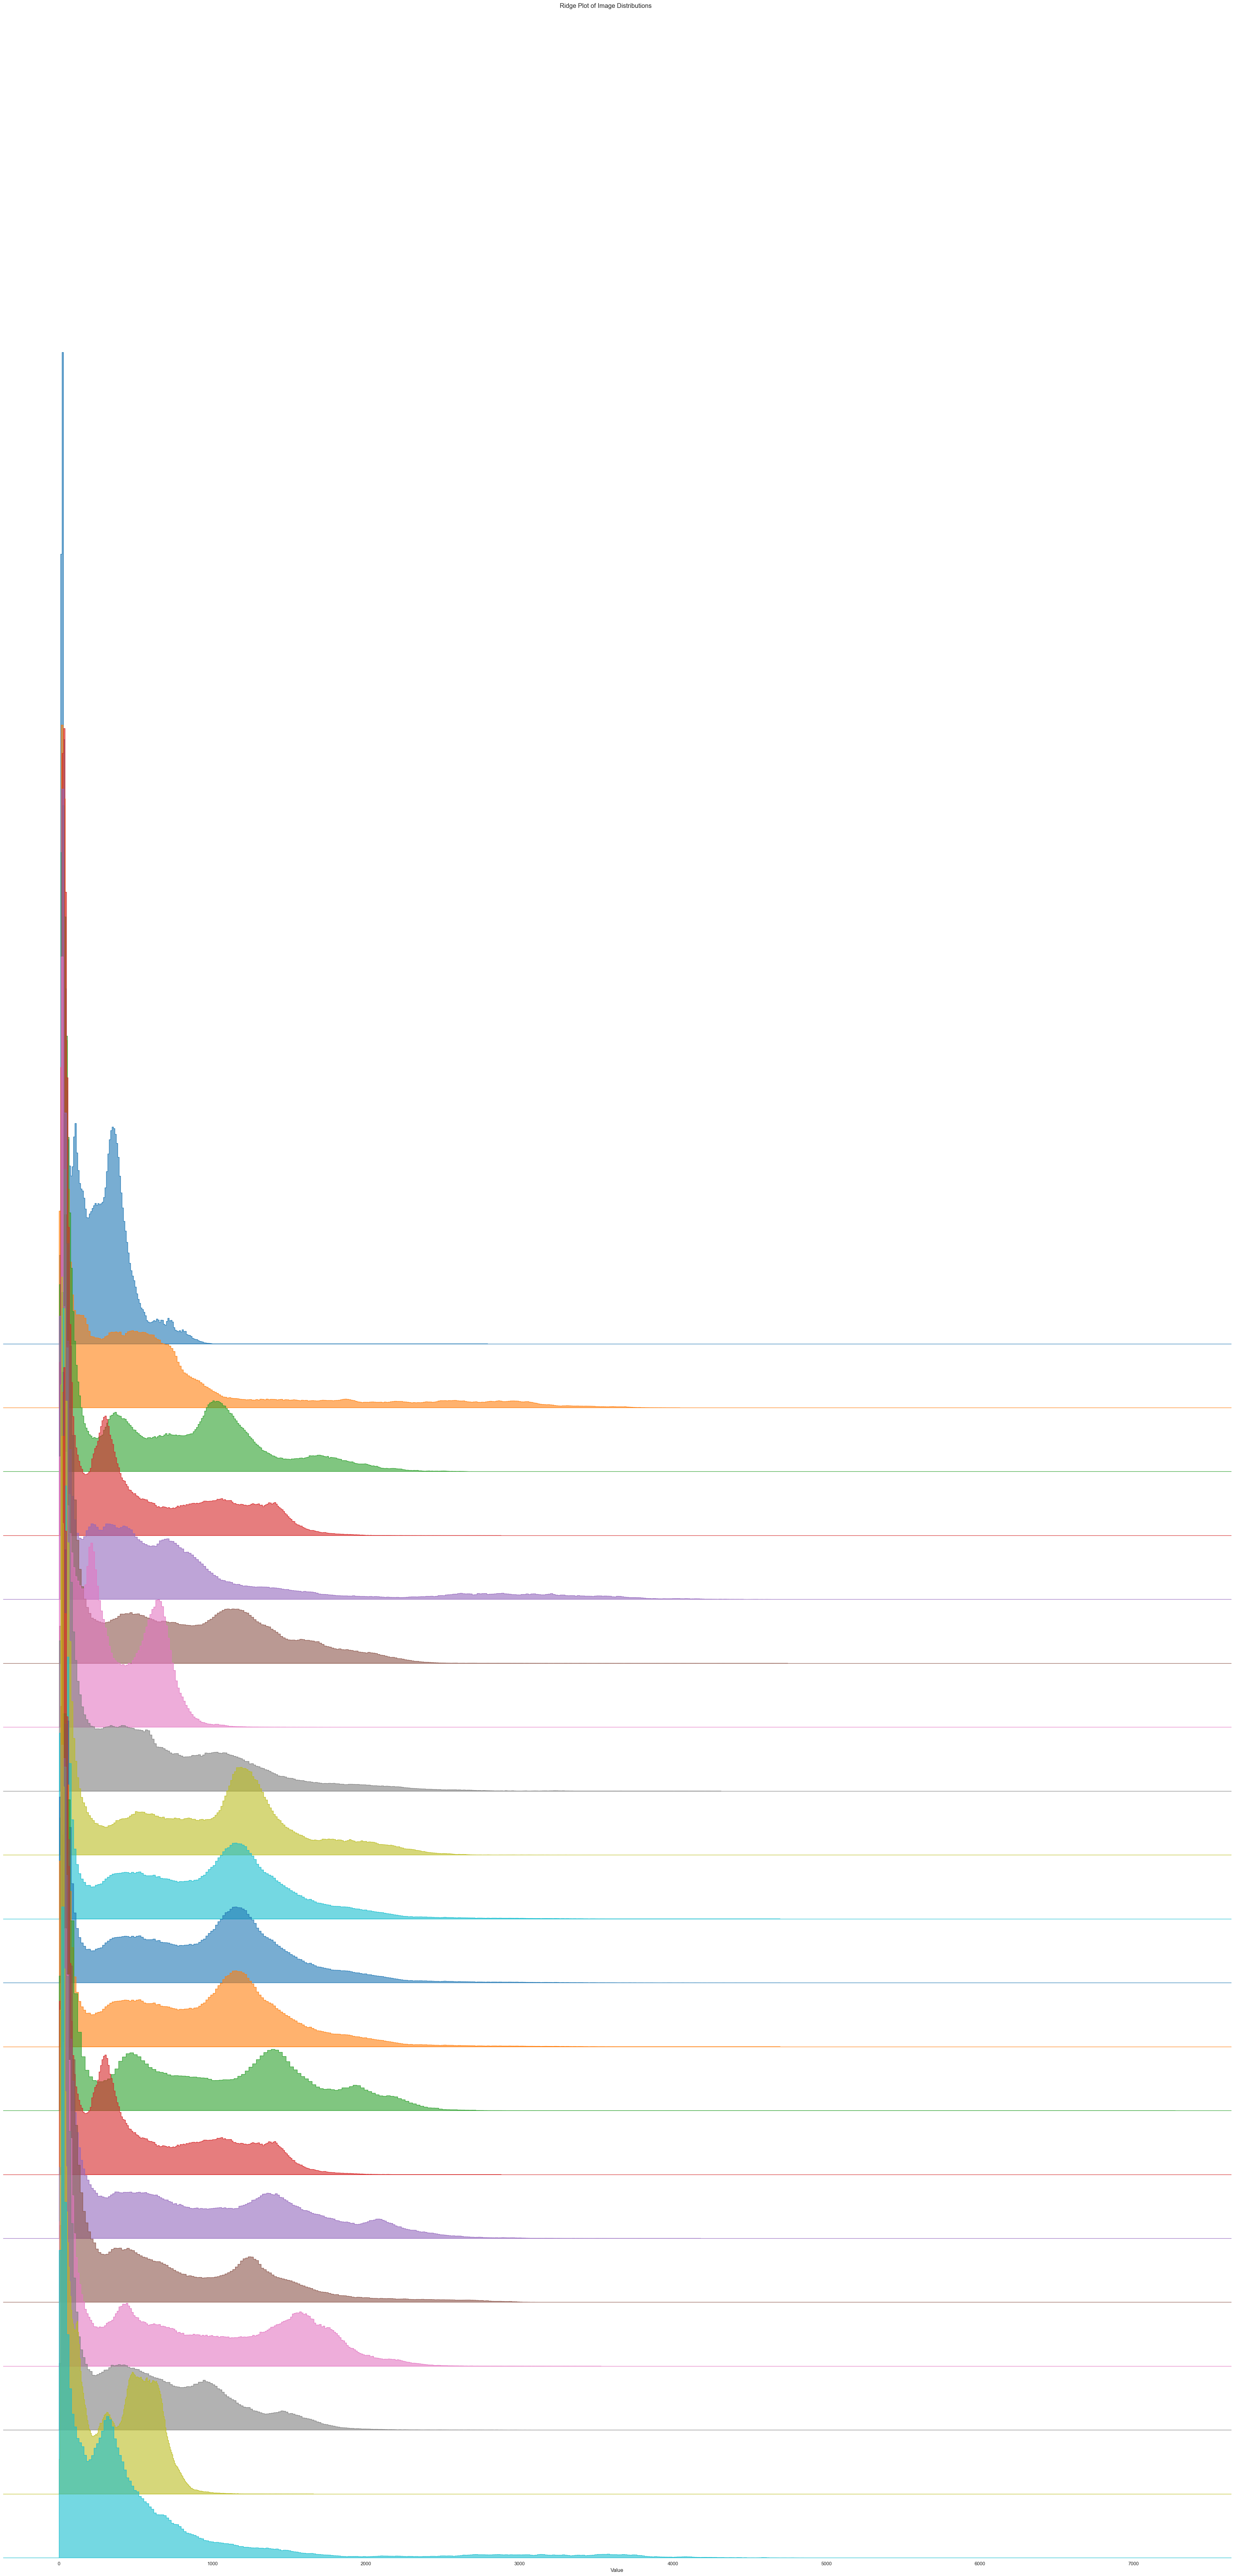

In [13]:
################################### MIN MAX SCALER ##########################################
from sklearn.preprocessing import MinMaxScaler

MinMax_scaler = MinMaxScaler()

all_pixels = np.array(helpers.recursive_flatten(all_images)).reshape(-1, 1)
print(all_pixels.shape)
MinMax_scaler = MinMax_scaler.fit(all_pixels)
################################################################################################



minmax_scaled_images = [clip_and_scale(img, clip=False, scaler=MinMax_scaler) for img in randomly_selected_images]

records = []

df = pd.concat([
pd.DataFrame({
    "value": helpers.recursive_flatten(img),
    "dataset": f"Img {i}"
})
for i, img in enumerate(randomly_selected_images)
])
        

# Plot
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df, row="dataset", hue="dataset", aspect=10, height=4, palette="tab10")

# Draw density curves
g.map(sns.histplot, "value", bins=300, stat="density", element="step", fill=True, alpha=0.6)


# Add baseline
g.map(plt.axhline, y=0, lw=1, clip_on=False)

# Overlap plots
g.figure.subplots_adjust(hspace=-0.95)

# Remove axes details
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.xlabel("Value")
plt.suptitle("Ridge Plot of Image Distributions", y=1.02)

In [15]:
#Grab a certain random image
random_id = random.randint(0, len(all_images))
random_img = all_images[20]

  0%|          | 0/105 [00:00<?, ?it/s]

100%|██████████| 105/105 [00:53<00:00,  1.96it/s]


finished clipping 105 images
finished flattening 105 images to 217025575 pixels
finished training the scaler


100%|██████████| 105/105 [00:40<00:00,  2.60it/s]


finished clipping 105 images
finished flattening 105 images to 217025575 pixels
finished training the scaler


Text(0.5, 1.0, 'Same Image after 99 percentile clipping + scaling')

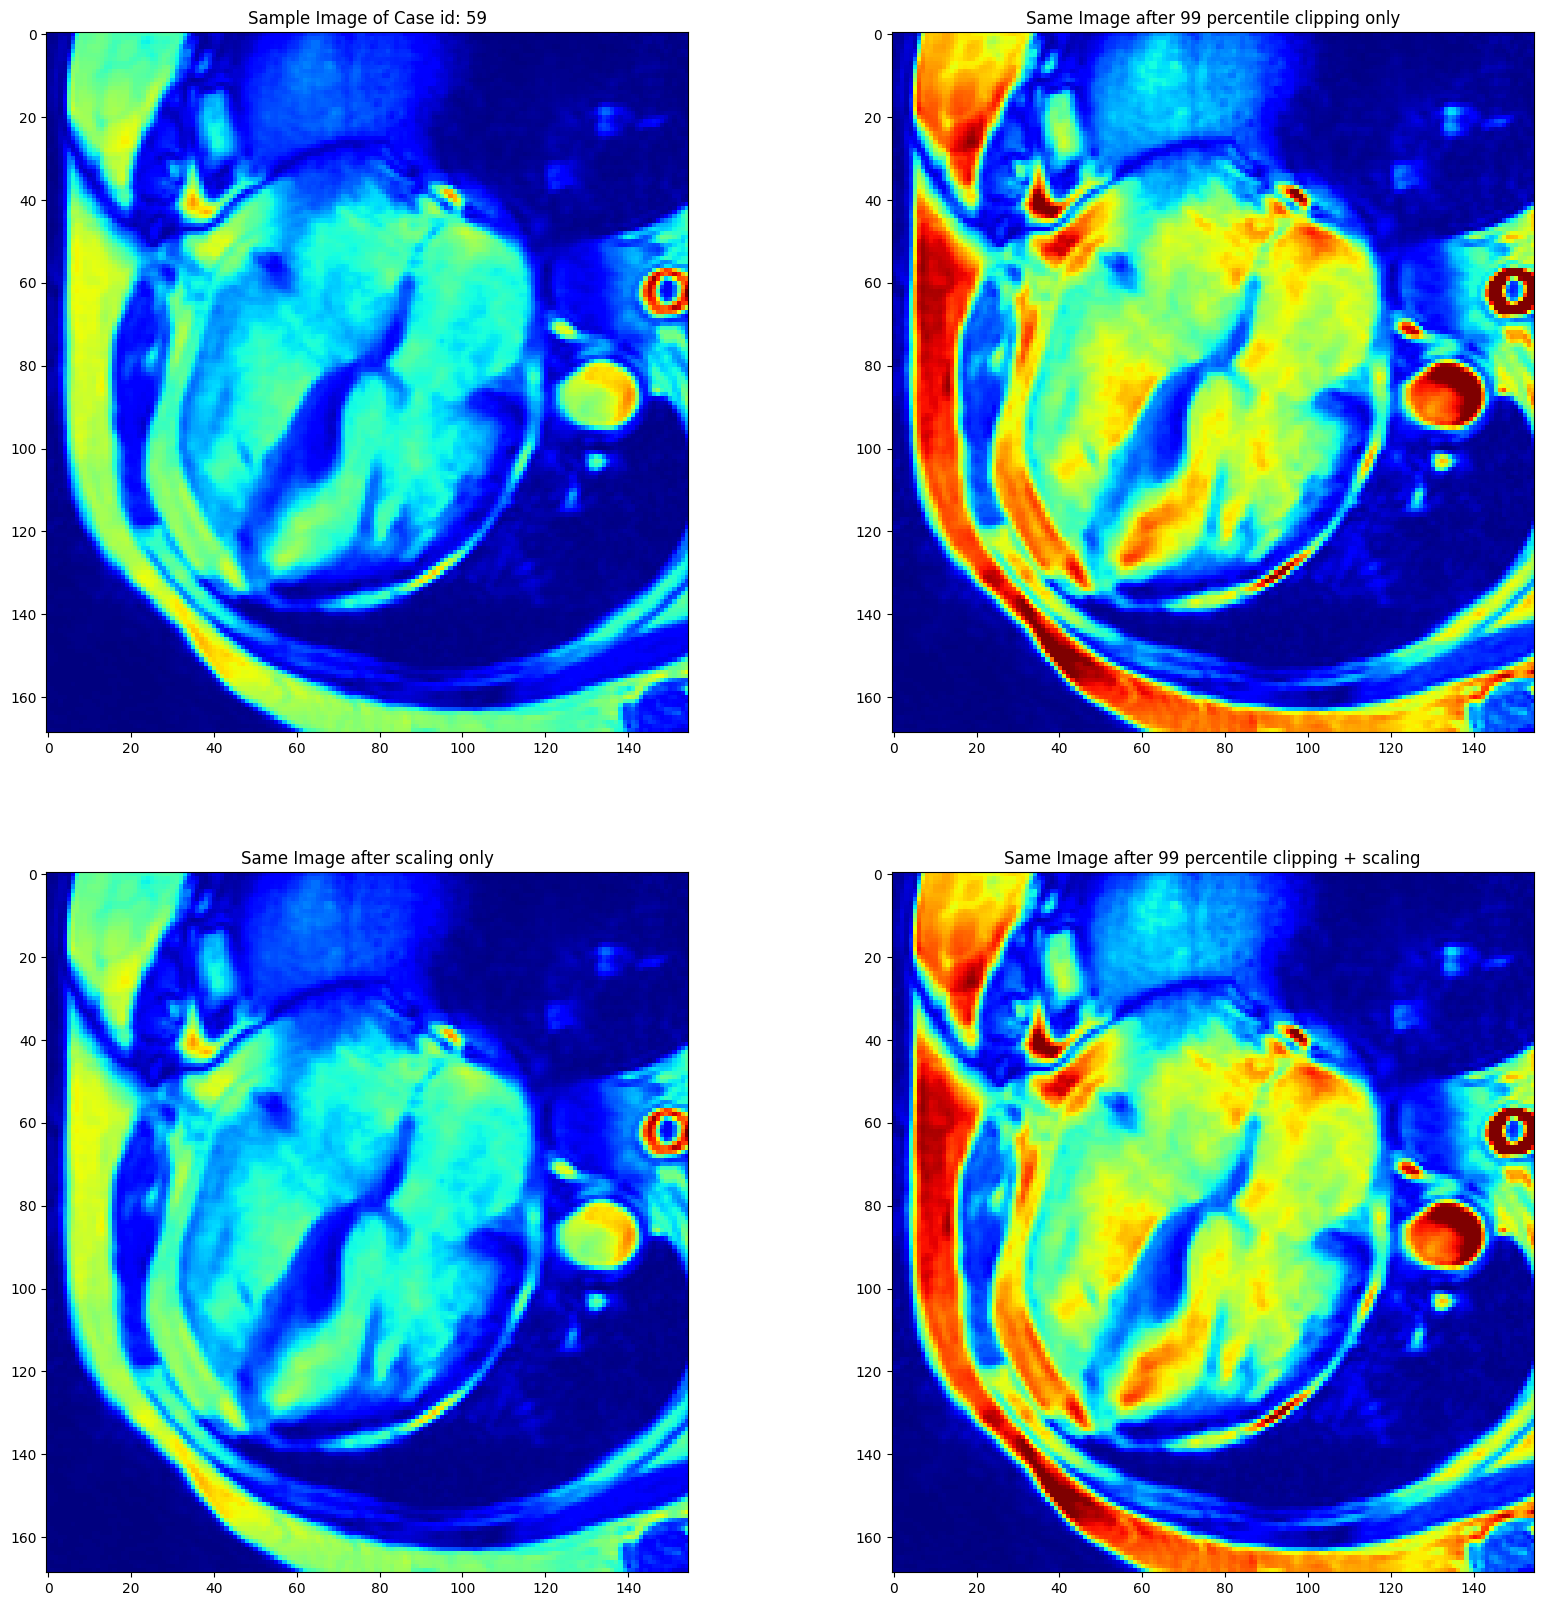

In [ ]:
# Visualizing an image before and after clipping
clipped_image, _ = clip_outliers_from_img(random_img)


#training a zscaler without clipping
zscaler_no_clip, _ = helpers.train_scaler(all_images, StandardScaler, clip=False)
scaled_image = clip_and_scale(random_img, clip=False, scaler=zscaler_no_clip)


#training a zscaler after clipping
zscaler_clipped, _ = helpers.train_scaler(all_images, StandardScaler, clip=True)
clipped_and_scaled_image = clip_and_scale(random_img, clip=True, scaler=zscaler_clipped)



figure,axis = plt.subplots(2,2,figsize=(10, 10))
axis[0][0].imshow(random_img[:,:,1], cmap='jet')
axis[0][0].set_title(f"Sample Image of Case id: {random_id}")
axis[0][1].imshow(clipped_image[:,:,1], cmap='jet')
axis[0][1].set_title("Same Image after 99 percentile clipping only")
axis[1][0].imshow(scaled_image[:,:,1], cmap='jet')
axis[1][0].set_title("Same Image after scaling only")
axis[1][1].imshow(clipped_and_scaled_image[:,:,1], cmap='jet')
axis[1][1].set_title("Same Image after 99 percentile clipping + scaling")

Text(0.5, 1.0, 'Same Image after 99 percentile clipping + scaling')

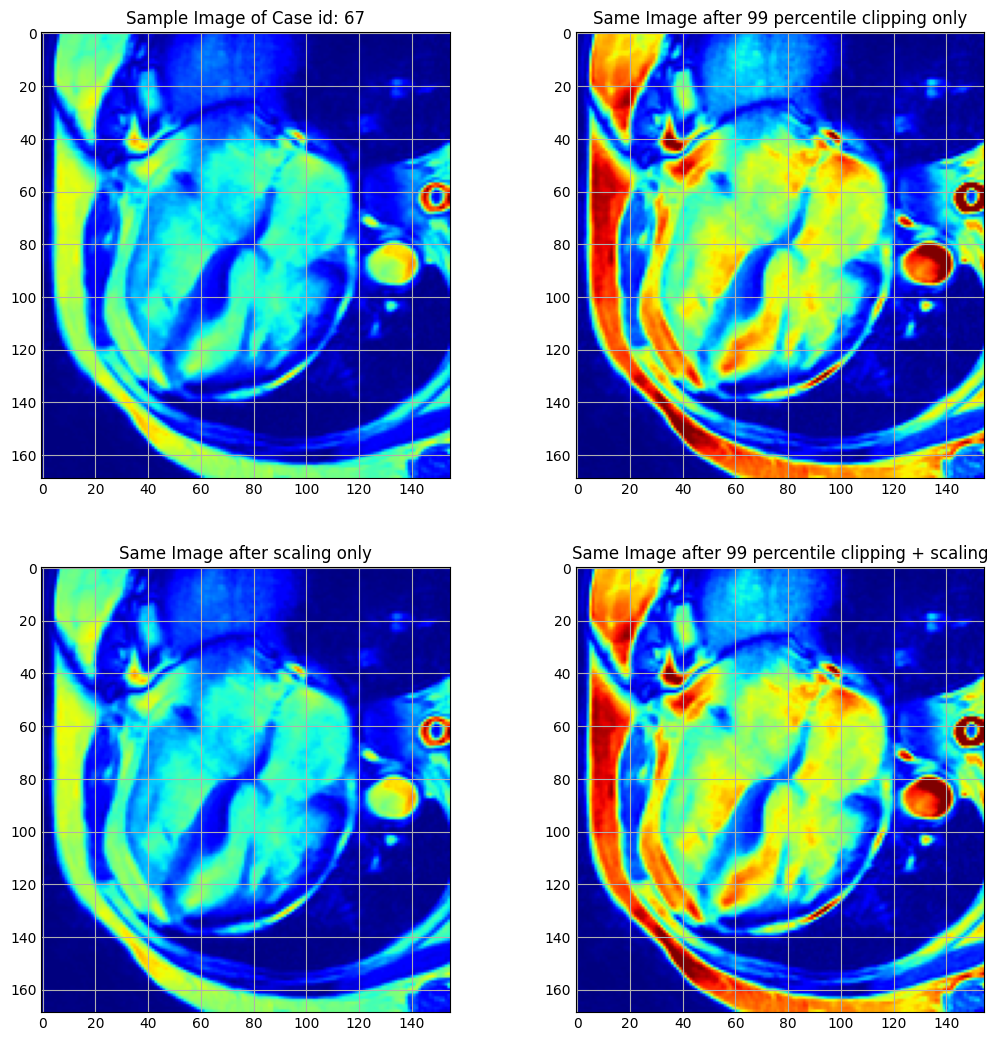

In [18]:
# Visualizing an image before and after clipping
clipped_image, _ = clip_outliers_from_img(random_img)


#training a MinMax scaler without clipping
MinMax_scaled = MinMaxScaler().fit_transform(random_img.reshape(-1, 1)).reshape(random_img.shape)

#training a zscaler after clipping
clipped_and_scaled_image = MinMaxScaler().fit_transform(clipped_image.reshape(-1, 1)).reshape(clipped_image.shape)



figure,axis = plt.subplots(2,2,figsize=(10, 10))
axis[0][0].imshow(random_img[:,:,1], cmap='jet')
axis[0][0].set_title(f"Sample Image of Case id: {random_id}")
axis[0][1].imshow(clipped_image[:,:,1], cmap='jet')
axis[0][1].set_title("Same Image after 99 percentile clipping only")
axis[1][0].imshow(MinMax_scaled[:,:,1], cmap='jet')
axis[1][0].set_title("Same Image after scaling only")
axis[1][1].imshow(clipped_and_scaled_image[:,:,1], cmap='jet')
axis[1][1].set_title("Same Image after 99 percentile clipping + scaling")

